In [2]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from statsmodels.tsa.stattools import adfuller
from Src.Data_utils import differencing
from Src.Data_utils import cointegration
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from statsmodels.tsa.vector_ar.vecm import select_coint_rank,select_order


load_dotenv()

##Connect to sql database
engine = create_engine(
    f"mysql+pymysql://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@"
    f"{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DB')}"
)

##Load the data from SQL

data = pd.read_sql("SELECT * FROM GDP_inference_clean", engine)

data.columns = ["date", "Labor Productivity", "Unemployment Rate", "Federal Funds Rate", "Inflation", "GDP", "Population","Investment","Government Spending","Consumption","Net Exports"]

data["GDP_per_capita"] = data["GDP"]*1000000 / data["Population"]


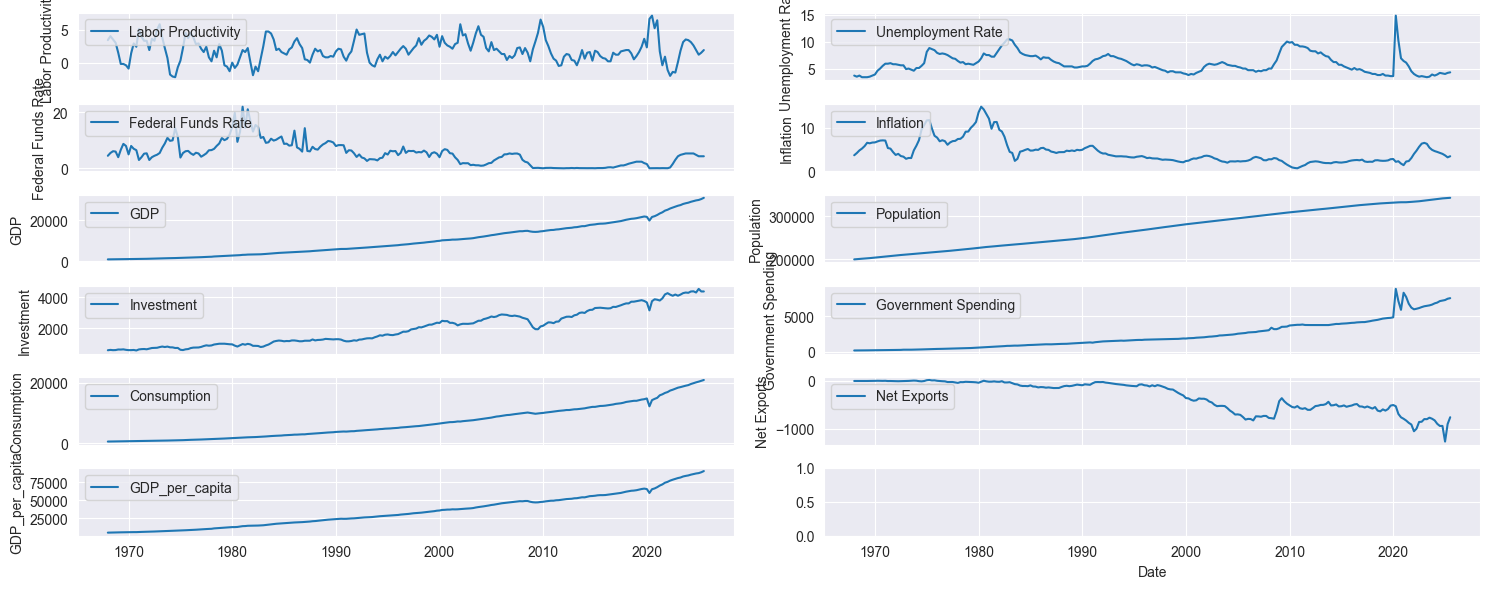

In [29]:
fig, axes = plt.subplots(6, 2, figsize=(15, 6), sharex=True)
axes = axes.flatten()
for i, column in enumerate(data.columns[1:]):
    axes[i].plot(data["date"], data[column], label=column, color='tab:blue')
    axes[i].set_ylabel(column)
    axes[i].legend(loc='upper left')

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [30]:
##Calculates unit roots to formally test stationarity
def dickey_fuller_test(data_test,regression):
    if "date" in data_test.columns:
        data_test = data_test.drop(["date"], axis=1)
    for i in data_test.columns:
        adf_result = adfuller(data_test[i], regression=regression)
        print(f"{i}, ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}")

dickey_fuller_test(data[["GDP_per_capita","GDP","Investment","Government Spending","Population","Consumption"]],"ct")
dickey_fuller_test(data[["Labor Productivity","Unemployment Rate","Federal Funds Rate","Inflation","Net Exports"]],"c")

GDP_per_capita, ADF Statistic: 2.249881210687862, p-value: 1.0
GDP, ADF Statistic: 3.2337008825709592, p-value: 1.0
Investment, ADF Statistic: -2.036549105219975, p-value: 0.581391733518553
Government Spending, ADF Statistic: -0.23577322331766404, p-value: 0.9908730479359548
Population, ADF Statistic: -2.5289048055675365, p-value: 0.3136647837782893
Consumption, ADF Statistic: 2.2330101144967873, p-value: 1.0
Labor Productivity, ADF Statistic: -3.522273389418204, p-value: 0.007433156396686727
Unemployment Rate, ADF Statistic: -3.9838868315848677, p-value: 0.0014972749064154232
Federal Funds Rate, ADF Statistic: -2.695662776290606, p-value: 0.07479181001142415
Inflation, ADF Statistic: -1.4996660337160246, p-value: 0.5336765407823213
Net Exports, ADF Statistic: -0.730695893332531, p-value: 0.8386376111469622


In [31]:
cointegration(data[["GDP_per_capita","Investment","Government Spending","Labor Productivity","Inflation","Consumption","Net Exports"]])

(                     GDP_per_capita  Investment  Government Spending  \
 GDP_per_capita                  NaN    0.473148             0.163757   
 Investment                 0.473148         NaN             0.014595   
 Government Spending        0.163757    0.014595                  NaN   
 Labor Productivity         1.000000    0.993640             1.000000   
 Inflation                  0.992127    0.989268             0.948906   
 Consumption                0.839409    0.460513             0.000038   
 Net Exports                0.663742    0.465825             0.840329   
 
                      Labor Productivity  Inflation  Consumption  Net Exports  
 GDP_per_capita                 1.000000   0.992127     0.839409     0.663742  
 Investment                     0.993640   0.989268     0.460513     0.465825  
 Government Spending            1.000000   0.948906     0.000038     0.840329  
 Labor Productivity                  NaN   0.051462     0.030847     0.031620  
 Inflation    

In [32]:
##Differencing the data and calculating Dickey Fuller on the new data
exclude = ["Unemployment Rate","GDP","Population"]
data_i1 = data.loc[:, ~data.columns.isin(exclude)]

Differenced_data = differencing(data_i1)
dickey_fuller_test(Differenced_data,"c")
##All time series except for population is I(1)

diffed_Labor Productivity, ADF Statistic: -6.646157567692941, p-value: 5.2593246551510045e-09
diffed_Federal Funds Rate, ADF Statistic: -5.788369026389358, p-value: 4.938174026677892e-07
diffed_Inflation, ADF Statistic: -5.586555474882141, p-value: 1.3588102014396112e-06
diffed_Investment, ADF Statistic: -14.940314529166752, p-value: 1.3256010175955307e-27
diffed_Government Spending, ADF Statistic: -7.7311993773177266, p-value: 1.124185832095007e-11
diffed_Consumption, ADF Statistic: -7.35380037222264, p-value: 9.900812597448531e-11
diffed_Net Exports, ADF Statistic: -4.050467023433782, p-value: 0.0011681256164295711
diffed_GDP_per_capita, ADF Statistic: -4.146364400972452, p-value: 0.0008110401893400719


In [33]:
Differenced_data=pd.concat([Differenced_data,data[["Unemployment Rate", "Federal Funds Rate"]]],axis=1)
Differenced_data.head()


,diffed_Labor Productivity,diffed_Federal Funds Rate,diffed_Inflation,diffed_Investment,diffed_Government Spending,diffed_Consumption,diffed_Net Exports,diffed_GDP_per_capita,Unemployment Rate,Federal Funds Rate
1,0.6,1.00,0.503967,22.673,6.380,13.1,0.695,115.043252,3.5,5.50
2,-0.5,0.63,0.597248,-16.784,2.564,19.2,-0.099,70.064828,3.7,6.13
3,-0.5,-0.13,0.429516,6.512,3.973,8.4,-0.705,71.892466,3.4,6.00
4,-1.5,-2.00,0.563605,35.635,-2.105,11.9,-0.706,114.841795,3.4,4.00
5,-1.7,2.63,0.759423,-3.775,6.875,10.4,0.865,67.201352,3.4,6.63


In [34]:
##This function tests cointgeration between every time series combination and returns the p-values and significant combinations
cointegration(data_i1)
print(data_i1)

          date  Labor Productivity  Federal Funds Rate  Inflation  Investment  \
0   1968-01-01                 3.4                4.50   3.651861     592.754   
1   1968-04-01                 4.0                5.50   4.155828     615.427   
2   1968-07-01                 3.5                6.13   4.753076     598.643   
3   1968-10-01                 3.0                6.00   5.182592     605.155   
4   1969-01-01                 1.5                4.00   5.746197     640.790   
..         ...                 ...                 ...        ...         ...   
226 2024-07-01                 2.6                5.33   4.182299    4392.176   
227 2024-10-01                 1.9                4.83   3.975247    4315.564   
228 2025-01-01                 1.2                4.33   3.624696    4547.947   
229 2025-04-01                 1.5                4.33   3.178169    4382.819   
230 2025-07-01                 1.9                4.33   3.427070    4383.186   

     Government Spending  C

In [35]:
lag_order = select_order(data_i1.iloc[:,1:], maxlags=10)
print(lag_order.summary())

##Johansen cointegration test using r metric
rank_test = select_coint_rank(data_i1.iloc[:,1:],
                              det_order=1,
                              k_ar_diff=2)
print(rank_test.summary())
## There exists 2 cointegration relations that we need to adjust for

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        46.91       48.02   2.367e+20       47.36
1        45.78       47.87   7.611e+19       46.62
2        44.83       47.92   2.984e+19       46.08
3        43.57      47.64*   8.486e+18       45.21
4        43.12       48.18   5.532e+18      45.17*
5        43.19       49.24   6.075e+18       45.63
6        43.10       50.14   5.780e+18       45.94
7        42.75       50.77  4.273e+18*       45.99
8        42.74       51.75   4.511e+18       46.38
9       42.63*       52.62   4.348e+18       46.66
10       42.66       53.64   4.986e+18       47.10
--------------------------------------------------
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   8          248.3          175.2
  1   8          166.0          139.3
 

In [36]:
##Calculate descriptive statistics on stationary time series
Differenced_data.describe()

,diffed_Labor Productivity,diffed_Federal Funds Rate,diffed_Inflation,diffed_Investment,diffed_Government Spending,diffed_Consumption,diffed_Net Exports,diffed_GDP_per_capita,Unemployment Rate,Federal Funds Rate
count,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,231.000000,231.000000
mean,-0.006522,-0.000739,-0.000977,16.480139,32.186713,89.027826,-3.294017,375.137419,5.990476,5.128528
std,1.141783,1.924895,0.585920,81.742111,353.205739,243.481755,47.950999,637.232192,1.788464,4.155800
min,-4.700000,-10.320000,-2.307504,-512.766000,-1717.262000,-2619.100000,-325.938000,-5465.242335,3.400000,0.040000
25%,-0.700000,-0.377500,-0.178467,-16.884500,6.441750,34.675000,-17.406000,168.298866,4.700000,1.750000
50%,-0.100000,0.020000,0.001762,11.793000,18.061500,71.550000,-3.041000,291.315473,5.700000,5.050000
75%,0.700000,0.522500,0.206483,54.360500,35.751000,122.150000,5.274250,493.697791,7.150000,6.930000
max,4.300000,8.950000,2.422274,592.018000,4024.750000,2058.000000,364.805000,5241.556463,14.800000,22.000000


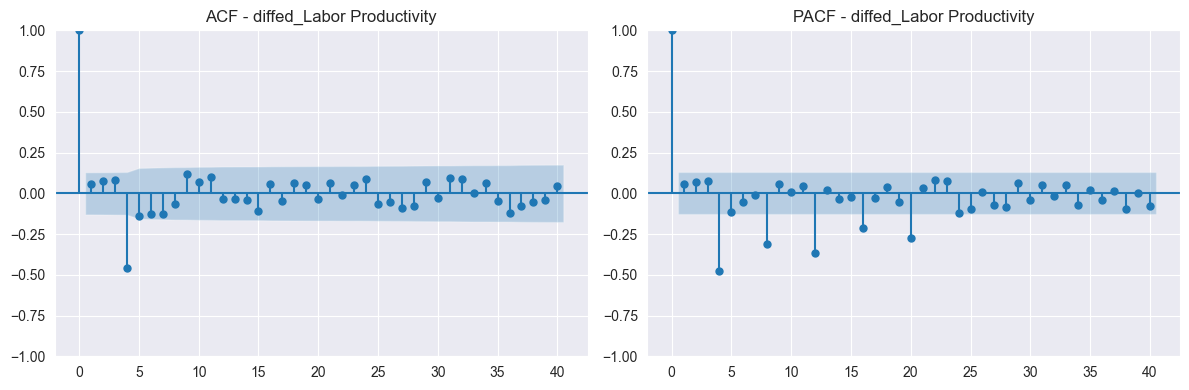

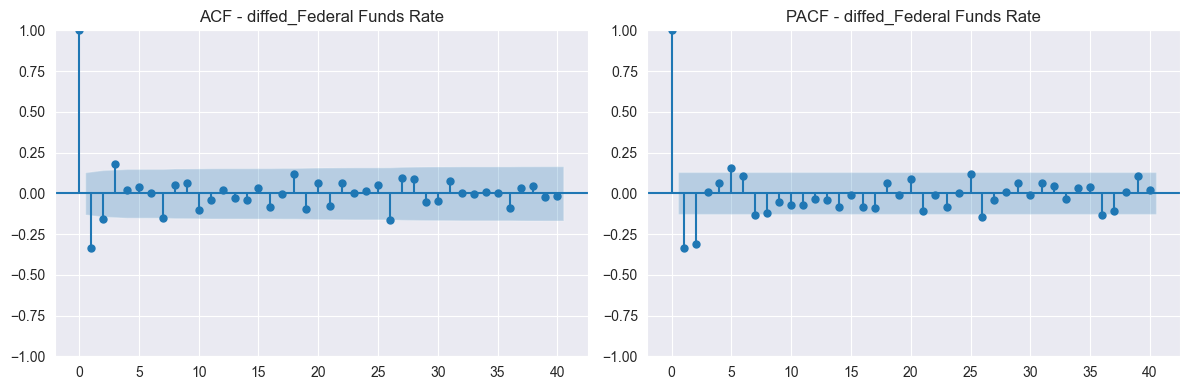

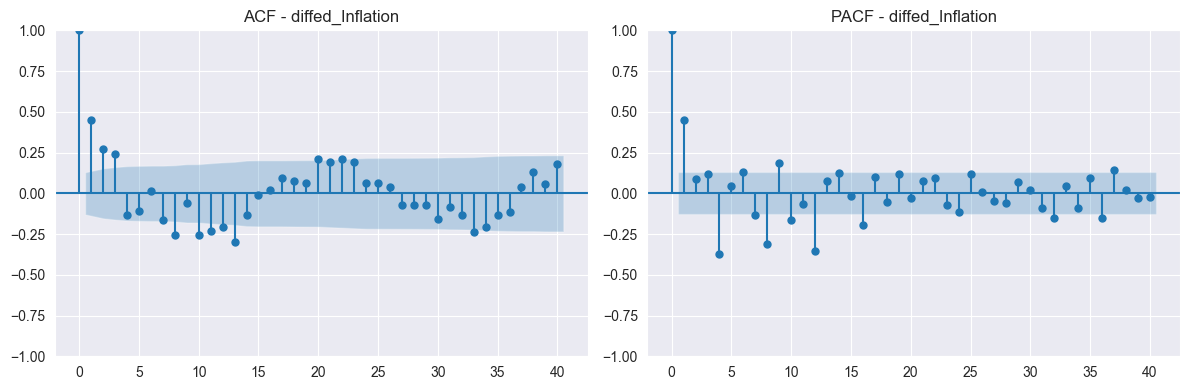

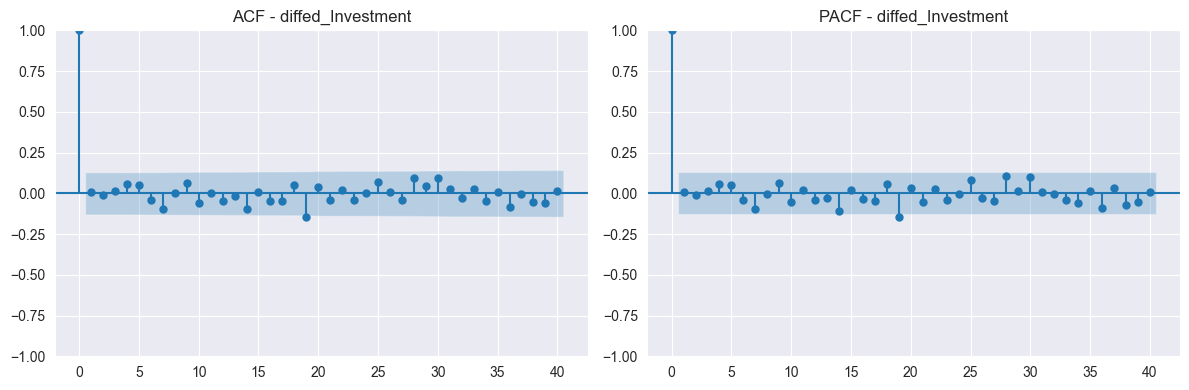

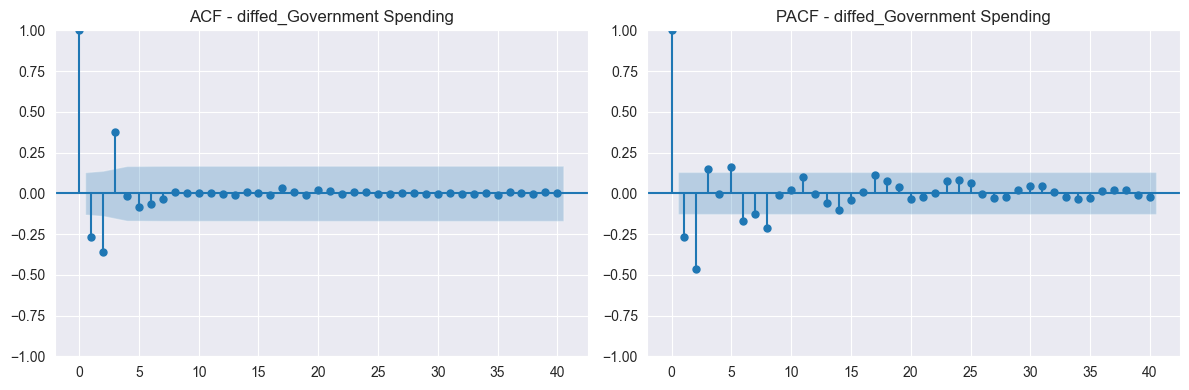

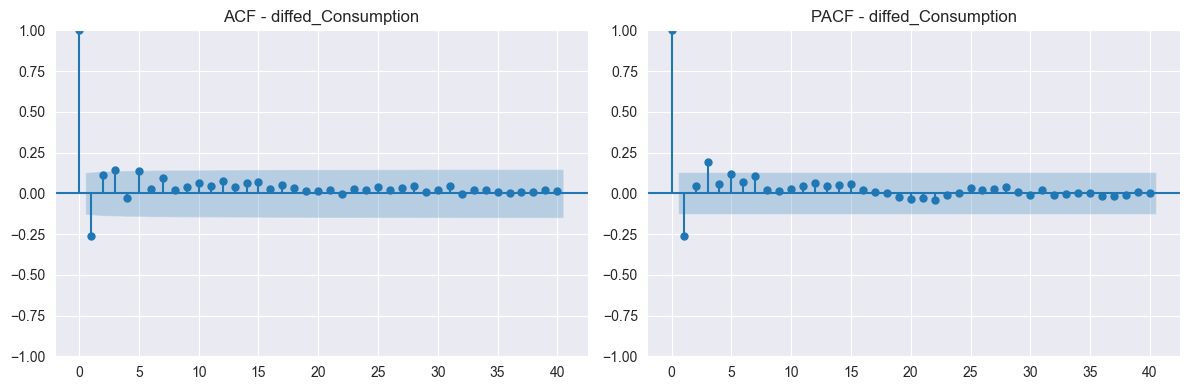

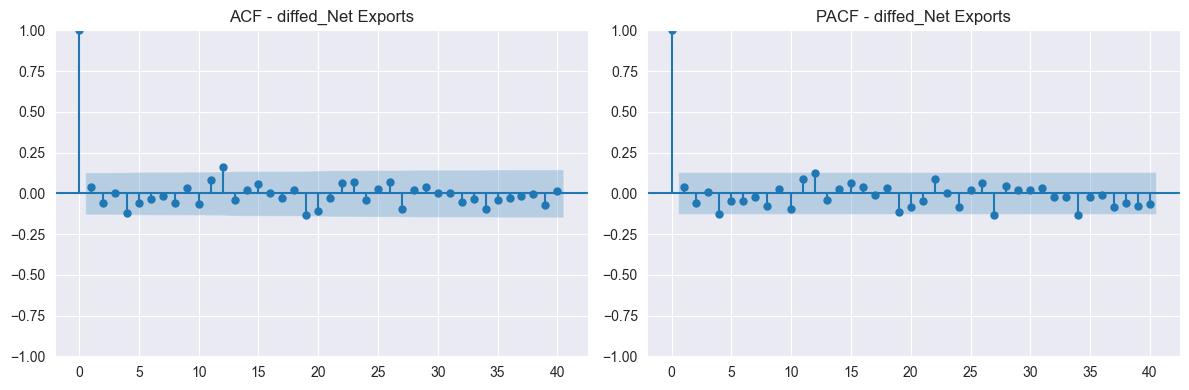

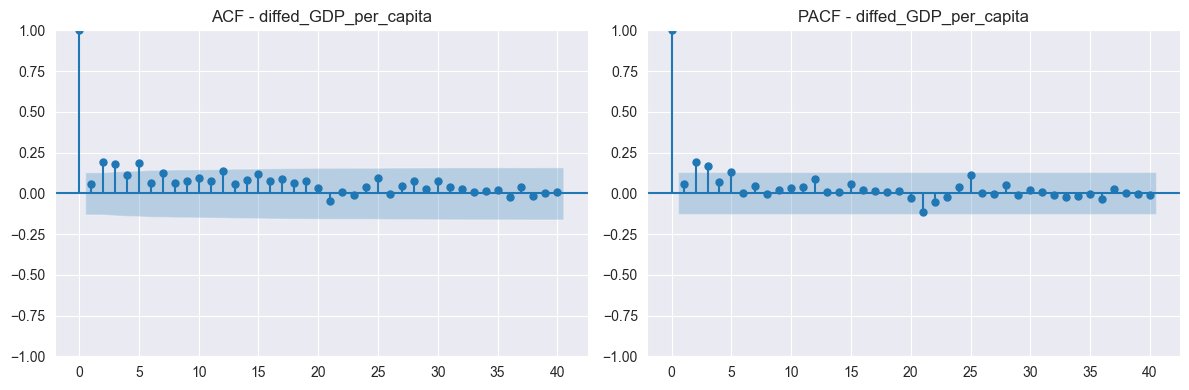

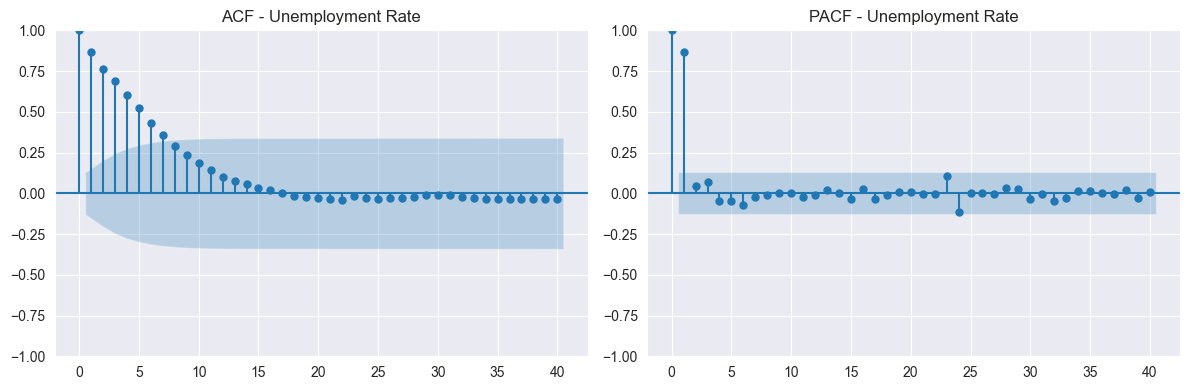

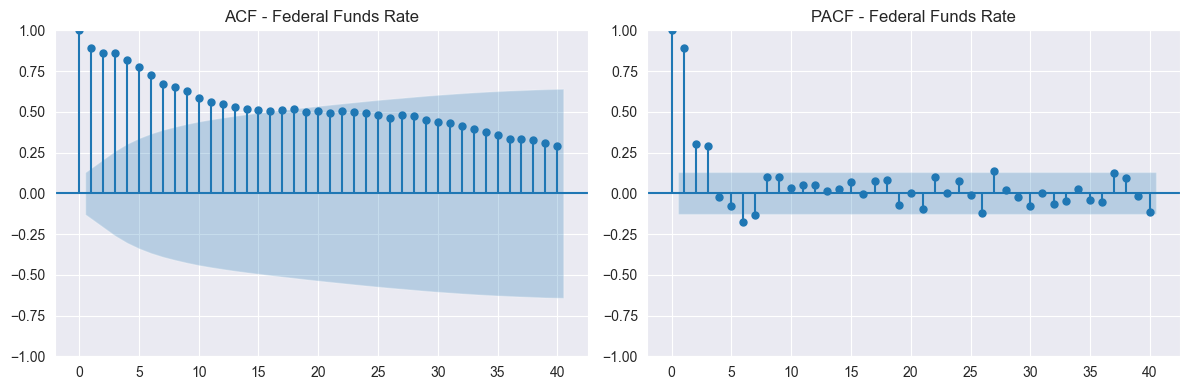

In [37]:
for column in Differenced_data.columns:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(Differenced_data[column].dropna(), ax=axes[0], lags=40)
    axes[0].set_title(f"ACF - {column}")

    plot_pacf(Differenced_data[column].dropna(), ax=axes[1], lags=40, method="ywm")
    axes[1].set_title(f"PACF - {column}")

    plt.tight_layout()
    plt.show()

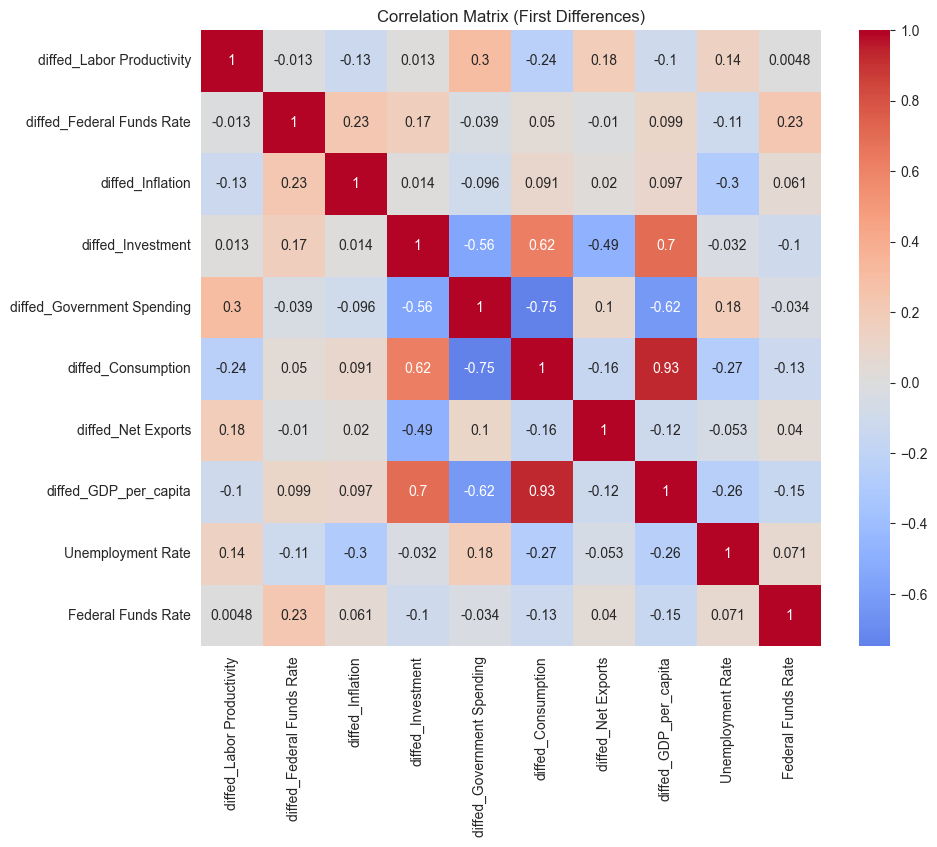

In [38]:
corr_diff = Differenced_data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_diff, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (First Differences)")
plt.show()


The most important thing is that variables such as GDP per capita, investment, government spending, inflation and labor productivity are I(1), while federal funds rate and unemployment are I(0).

From BIC we can see that the optimal lag order is 3. I use BIC because it more penalizes the number of parameters more.

Johansen test indicates that there exists 2 cointegration relationships in our data that we need to adjust for. After looking at all the pairs for cointegration GDP and Goverment spending suggest a common long term relationship.

ACF for federal funds rate looks sinusoidal indicating mild seasonality. However, from economic theory we know that FED doesn't adjust their interest rates according to the season.

As expected in correlations goverment spending and investment are highly correlated with GDP this is because of GDP structure: GDP= C+I+G-NX. Furthemore federal funds rate is negatively correlated with employment this also makes sense because one of FEDS economics targets is unemployment.